# Zhang representative sorting

Pipeline : 

- **ground truth** generation using `uta_gt`
- **score → category** conversion
- **reference / non-reference** split
- Zhang model **training**
- prediction, metrics, and visualizations

In [53]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path(".").resolve()
if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

from uta_core import PeakConfig, uta_gt, detect_monotonic_flags
from zhang_core import (
    fit_zhang_representative,
    predict_categories,
    make_scoring_fn,
    check_consistency,
    adjust_preferences_minimum,
)

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 1. Helpers

Les helpers ci-dessous couvrent :

- conversion des scores GT en catégories
- split stratifié référence / non-référence
- injection de bruit sur les labels de référence
- métriques simples
- visualisations
- fonction centrale `run_trial_zhang(...)`


In [54]:
def scores_to_categories_equal_width(scores, q):
    """
    Convert continuous scores into categories {1, ..., q}
    using equal-width bins on [min(scores), max(scores)].
    """
    scores = np.asarray(scores, dtype=float).ravel()
    if q < 2:
        raise ValueError("q must be >= 2.")

    s_min = float(scores.min())
    s_max = float(scores.max())

    if np.isclose(s_min, s_max):
        cats = np.ones_like(scores, dtype=int)
        edges = np.linspace(s_min, s_max + 1e-9, q + 1)
        return cats, edges

    edges = np.linspace(s_min, s_max, q + 1)
    # searchsorted on internal cut points
    cats = np.searchsorted(edges[1:-1], scores, side="right") + 1
    cats = np.clip(cats, 1, q).astype(int)
    return cats, edges


def split_reference_nonreference(X, y, ref_ratio=0.2, seed=0, stratified=True):
    """
    Split alternatives into:
      - reference assignments (train)
      - non-reference alternatives (test)

    Returns
    -------
    X_ref, y_ref, X_test, y_test, ref_idx, test_idx
    """
    X = np.asarray(X)
    y = np.asarray(y).astype(int).ravel()

    n = len(y)
    if X.shape[0] != n:
        raise ValueError("X and y must have same number of rows.")
    if not (0 < ref_ratio < 1):
        raise ValueError("ref_ratio must be in (0, 1).")

    rng = np.random.default_rng(seed)
    all_idx = np.arange(n)

    if not stratified:
        rng.shuffle(all_idx)
        n_ref = max(1, int(round(ref_ratio * n)))
        ref_idx = np.sort(all_idx[:n_ref])
        test_idx = np.sort(all_idx[n_ref:])
        return X[ref_idx], y[ref_idx], X[test_idx], y[test_idx], ref_idx, test_idx

    ref_parts = []
    test_parts = []

    for cls in np.unique(y):
        cls_idx = np.where(y == cls)[0]
        cls_idx = rng.permutation(cls_idx)

        n_cls = len(cls_idx)
        n_ref_cls = int(round(ref_ratio * n_cls))

        # garder au moins 1 élément par classe dans ref et test si possible
        if n_cls >= 2:
            n_ref_cls = min(max(1, n_ref_cls), n_cls - 1)
        else:
            n_ref_cls = 1

        ref_parts.append(cls_idx[:n_ref_cls])
        test_parts.append(cls_idx[n_ref_cls:])

    ref_idx = np.sort(np.concatenate(ref_parts)) if ref_parts else np.array([], dtype=int)
    test_idx = np.sort(np.concatenate(test_parts)) if test_parts else np.array([], dtype=int)

    # fallback si jamais test est vide
    if len(test_idx) == 0:
        remaining = np.setdiff1d(all_idx, ref_idx)
        if len(remaining) == 0 and len(ref_idx) > 1:
            test_idx = np.array([ref_idx[-1]])
            ref_idx = ref_idx[:-1]
        else:
            test_idx = remaining

    return X[ref_idx], y[ref_idx], X[test_idx], y[test_idx], ref_idx, test_idx


def add_label_noise_to_categories(y, q, noise_level=0.0, mode="adjacent", seed=0):
    """
    Add label noise to categories in {1, ..., q}.

    mode:
      - 'adjacent'    : flip to neighbouring category when possible
      - 'random_other': flip to any other category
    """
    y = np.asarray(y).astype(int).copy()
    if noise_level <= 0:
        return y

    rng = np.random.default_rng(seed)
    n = len(y)
    mask = rng.random(n) < noise_level

    for i in np.where(mask)[0]:
        current = int(y[i])

        if mode == "adjacent":
            candidates = []
            if current - 1 >= 1:
                candidates.append(current - 1)
            if current + 1 <= q:
                candidates.append(current + 1)
            if not candidates:
                continue
            y[i] = int(rng.choice(candidates))

        elif mode == "random_other":
            candidates = [c for c in range(1, q + 1) if c != current]
            y[i] = int(rng.choice(candidates))

        else:
            raise ValueError("mode must be 'adjacent' or 'random_other'.")

    return y


def accuracy_score_simple(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return float(np.mean(y_true == y_pred))


def adjacent_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_pred = np.asarray(y_pred).astype(int).ravel()
    return float(np.mean(np.abs(y_true - y_pred) <= 1))


def summarize_fit(fit):
    keys = ["status", "obj", "time_sec", "q", "approach", "epsilon", "b0", "bq"]
    summary = {k: fit.get(k) for k in keys if k in fit}
    if "thresholds" in fit:
        summary["thresholds"] = np.asarray(fit["thresholds"]).round(4).tolist()
    return summary


def plot_category_histogram(y, title="Category distribution"):
    y = np.asarray(y).astype(int)
    vals, counts = np.unique(y, return_counts=True)

    plt.figure(figsize=(6, 4))
    plt.bar(vals, counts)
    plt.xticks(vals)
    plt.xlabel("Category")
    plt.ylabel("Count")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.show()


def plot_thresholds_and_scores(X, fit, y_true=None, title="Predicted scores and thresholds", normalize=True):
    V_fn = make_scoring_fn(fit)
    scores = V_fn(X)

    thresholds = np.asarray(fit["thresholds"], dtype=float)
    b0 = float(fit["b0"])
    bq = float(fit["bq"])
    b_full = np.concatenate([[b0], thresholds, [bq]])

    order = np.argsort(scores)
    scores_sorted = scores[order]

    y_true_sorted = None
    y_pred_sorted = None
    if y_true is not None:
        y_true = np.asarray(y_true).astype(int).ravel()
        y_pred = predict_categories(X, fit)
        y_true_sorted = y_true[order]
        y_pred_sorted = y_pred[order]

    if normalize:
        denom = max(bq - b0, 1e-12)
        scores_plot = (scores_sorted - b0) / denom
        b_plot = (b_full - b0) / denom
        y_label = "Normalized score"
    else:
        scores_plot = scores_sorted
        b_plot = b_full
        y_label = "Score V(a)"

    plt.figure(figsize=(10, 4))
    x_idx = np.arange(len(scores_plot))
    if y_true_sorted is None:
        plt.plot(scores_plot, marker="o", linestyle="", alpha=0.75, color="tab:blue")
    else:
        cmap = plt.get_cmap("tab10")
        cats = np.unique(y_true_sorted)
        for idx_cat, cat in enumerate(cats):
            mask = y_true_sorted == cat
            plt.scatter(x_idx[mask], scores_plot[mask], s=52, alpha=0.85, color=cmap(idx_cat), label=f"true C{cat}")
    for h, b in enumerate(b_plot, start=0):
        is_internal = 0 < h < len(b_plot) - 1
        if not is_internal:
            continue
        plt.axhline(b, linestyle="--", alpha=0.9, color="tab:red", linewidth=2.2, label=f"b{h}")
    plt.title(title)
    plt.xlabel("Sorted alternatives")
    plt.ylabel(y_label)
    plt.grid(alpha=0.2)
    plt.legend(ncol=min(len(b_full), 6))
    plt.show()

    if y_true is not None:
        df_tmp = pd.DataFrame({"score": scores, "y_true": y_true, "y_pred": y_pred}).sort_values("score")
        display(df_tmp.head(20))


def plot_marginals_and_weights(gt, fit):
    """
    Compare GT marginals vs inferred Zhang marginals and display a weight histogram.
    """
    gt_u = np.asarray(gt["u_values"], dtype=float)
    gt_w = np.asarray(gt["weights"], dtype=float)
    gt_breaks = gt["breaks"]

    inf_u = np.asarray(fit["v_values"], dtype=float)
    inf_breaks = fit["breaks"]

    m = gt_u.shape[0]

    inf_u_norm = inf_u.copy()
    for j in range(m):
        mn, mx = inf_u_norm[j].min(), inf_u_norm[j].max()
        if mx > mn:
            inf_u_norm[j] = (inf_u_norm[j] - mn) / (mx - mn)

    ncols = 2
    nrows = int(np.ceil(m / ncols))
    plt.figure(figsize=(12, 4 * nrows))

    for j in range(m):
        plt.subplot(nrows, ncols, j + 1)
        plt.plot(gt_breaks[j], gt_u[j], marker="o", label=f"GT u_{j+1}")
        plt.plot(inf_breaks[j], inf_u_norm[j], marker="s", linestyle="--", label=f"Inferred v_{j+1} (norm)")
        plt.title(f"Criterion {j+1} | GT weight={gt_w[j]:.3f}")
        plt.xlabel("Criterion value")
        plt.ylabel("Marginal value")
        plt.grid(alpha=0.2)
        plt.legend()

    plt.tight_layout()
    plt.show()

    gt_w_norm = gt_w / gt_w.sum() if gt_w.sum() > 0 else gt_w
    inf_weight_proxy = np.ptp(inf_u, axis=1)
    if inf_weight_proxy.sum() > 0:
        inf_weight_proxy = inf_weight_proxy / inf_weight_proxy.sum()
    else:
        inf_weight_proxy = np.full(m, 1.0 / m)

    x = np.arange(m)
    width = 0.38
    plt.figure(figsize=(8, 4))
    plt.bar(x - width / 2, gt_w_norm, width=width, label="GT weights")
    plt.bar(x + width / 2, inf_weight_proxy, width=width, label="Inferred weight proxy")
    plt.xticks(x, [f"C{j+1}" for j in range(m)])
    plt.xlabel("Criterion")
    plt.ylabel("Relative weight")
    plt.title("Weight histogram: GT vs inferred Zhang proxy")
    plt.grid(axis="y", alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

**run_trial_zhang** executes one full experimental run.

Steps:
1. Generate synthetic alternatives
2. Generate ground truth marginal value functions
3. Convert global scores into categories
4. Select reference assignments
5. Optionally add noise to reference labels
6. Fit the Zhang representative sorting model
7. Evaluate predictive performance on unseen alternatives

In [55]:
def run_trial_zhang(
    *,
    seed=0,
    n_alt=120,
    m=5,
    L=5,
    q=3,
    ref_ratio=0.2,
    noise=0.0,
    noise_mode="adjacent",
    approach=2,
    k_non_mono=2,
    peak_mode="center",
    scale="minmax",
    epsilon_lb=1e-3,
    epsilon_ub=0.5,
    gurobi_params=None,
    repair_if_inconsistent=True,
    verbose=False,
):
    """
    One end-to-end Zhang trial:
      1) generate X
      2) build UTA ground truth
      3) convert GT scores -> categories
      4) split reference / non-reference
      5) optionally add noise on y_ref
      6) consistency check (+ optional repair)
      7) fit Zhang
      8) evaluate on train / test
    """
    rng = np.random.default_rng(seed)

    # 1) synthetic performance table
    X = rng.uniform(0.0, 1.0, size=(n_alt, m))

    # 2) shared ground truth from UTA
    peak_cfg = PeakConfig(mode=peak_mode)
    gt = uta_gt(
        X=X,
        L=L,
        seed=seed,
        scale=scale,
        n_non_monotonic=k_non_mono,
        peak_cfg=peak_cfg,
        noise_level=0.0,
    )

    scores_gt = np.asarray(gt["scores"], dtype=float)

    # 3) score -> categories
    y_all, edges = scores_to_categories_equal_width(scores_gt, q=q)

    # 4) reference / non-reference split
    X_ref, y_ref, X_test, y_test, ref_idx, test_idx = split_reference_nonreference(
        X, y_all, ref_ratio=ref_ratio, seed=seed, stratified=True
    )

    # 5) noisy labels only on the reference set
    y_ref_noisy = add_label_noise_to_categories(
        y_ref, q=q, noise_level=noise, mode=noise_mode, seed=seed + 123
    )

    # 6) consistency + optional repair
    consistency = check_consistency(
        X=X,
        ar_idx=ref_idx,
        B=y_ref_noisy,
        q=q,
        L=L,
        scale=scale,
        gurobi_params=gurobi_params,
        verbose=verbose,
    )

    B_fit = y_ref_noisy.copy()
    used_adjustment = False
    adjustment = None

    if repair_if_inconsistent and consistency.get("objective", 1.0) > 1e-9:
        adjustment = adjust_preferences_minimum(
            X=X,
            ar_idx=ref_idx,
            B=y_ref_noisy,
            q=q,
            L=L,
            scale=scale,
            gurobi_params=gurobi_params,
            verbose=verbose,
        )
        B_fit = np.asarray(adjustment["B_star"]).astype(int)
        used_adjustment = True

    # 7) fit Zhang
    fit = fit_zhang_representative(
        X=X,
        ar_idx=ref_idx,
        B=B_fit,
        q=q,
        L=L,
        approach=approach,
        scale=scale,
        epsilon_lb=epsilon_lb,
        epsilon_ub=epsilon_ub,
        gurobi_params=gurobi_params,
        verbose=verbose,
    )

    # 8) predictions / metrics
    y_pred_ref = predict_categories(X_ref, fit)
    y_pred_test = predict_categories(X_test, fit)

    V_fn = make_scoring_fn(fit)
    scores_pred_all = V_fn(X)

    inferred_monotonic = detect_monotonic_flags(np.asarray(fit["v_values"], dtype=float))
    gt_monotonic = np.asarray(gt["is_monotonic"], dtype=bool)

    result = {
        "seed": seed,
        "n_alt": n_alt,
        "m": m,
        "L": L,
        "q": q,
        "ref_ratio": ref_ratio,
        "noise": noise,
        "noise_mode": noise_mode,
        "approach": approach,
        "k_non_mono": k_non_mono,
        "peak_mode": peak_mode,
        "scale": scale,
        "status": fit["status"],
        "obj": fit.get("obj"),
        "cpu_sec": fit.get("time_sec"),
        "epsilon": fit.get("epsilon"),
        "used_adjustment": used_adjustment,
        "consistency_obj": consistency.get("objective"),
        "acc_train": accuracy_score_simple(y_ref, y_pred_ref),
        "acc_train_noisy_target": accuracy_score_simple(y_ref_noisy, y_pred_ref),
        "acc_test": accuracy_score_simple(y_test, y_pred_test),
        "adj_acc_test": adjacent_accuracy(y_test, y_pred_test),
        "mono_recovery_acc": float(np.mean(inferred_monotonic == gt_monotonic)),
        "n_ref": len(ref_idx),
        "n_test": len(test_idx),
        "thresholds": np.asarray(fit["thresholds"], dtype=float),
        "ref_idx": ref_idx,
        "test_idx": test_idx,
        "y_all": y_all,
        "y_ref": y_ref,
        "y_ref_noisy": y_ref_noisy,
        "y_test": y_test,
        "y_pred_ref": y_pred_ref,
        "y_pred_test": y_pred_test,
        "scores_gt": scores_gt,
        "scores_pred_all": scores_pred_all,
        "gt": gt,
        "fit": fit,
        "consistency": consistency,
        "adjustment": adjustment,
        "X": X,
        "X_ref": X_ref,
        "X_test": X_test,
        "edges_gt": edges,
        "gt_monotonic": gt_monotonic,
        "inferred_monotonic": inferred_monotonic,
    }

    return result


## 2. Minimal run

Sanity check on a simple configuration.


In [56]:
CFG = dict(
    seed=42,
    n_alt=120,
    m=5,
    L=4,
    q=2,
    ref_ratio=0.2,
    noise=0.0,
    noise_mode="adjacent",
    approach=2,     # 1 = min complexity then max epsilon, 2 = max epsilon then min complexity
    k_non_mono=2,
    peak_mode="center",
    scale="minmax",
    epsilon_lb=1e-3,
    epsilon_ub=0.5,
    gurobi_params={"TimeLimit": 60},
    repair_if_inconsistent=True,
    verbose=False,
)

res = run_trial_zhang(**CFG)

summary = {
    "status": res["status"],
    "obj": res["obj"],
    "cpu_sec": res["cpu_sec"],
    "epsilon": res["epsilon"],
    "consistency_obj": res["consistency_obj"],
    "used_adjustment": res["used_adjustment"],
    "acc_train": res["acc_train"],
    "acc_train_noisy_target": res["acc_train_noisy_target"],
    "acc_test": res["acc_test"],
    "adj_acc_test": res["adj_acc_test"],
    "mono_recovery_acc": res["mono_recovery_acc"],
    "thresholds": np.round(res["thresholds"], 4),
}
summary

{'status': 2,
 'obj': 17.925168061426678,
 'cpu_sec': 0.014756100019440055,
 'epsilon': 0.4228254026203223,
 'consistency_obj': None,
 'used_adjustment': True,
 'acc_train': 0.9583333333333334,
 'acc_train_noisy_target': 0.9583333333333334,
 'acc_test': 0.78125,
 'adj_acc_test': 1.0,
 'mono_recovery_acc': 0.4,
 'thresholds': array([2.335])}

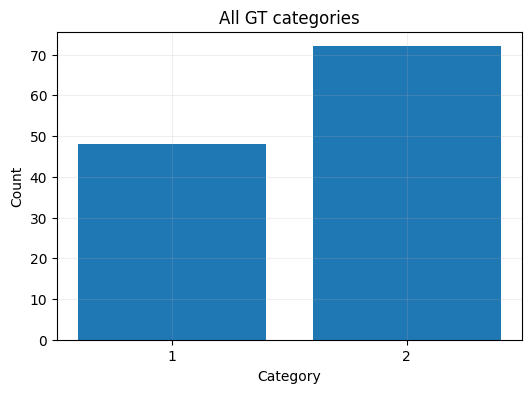

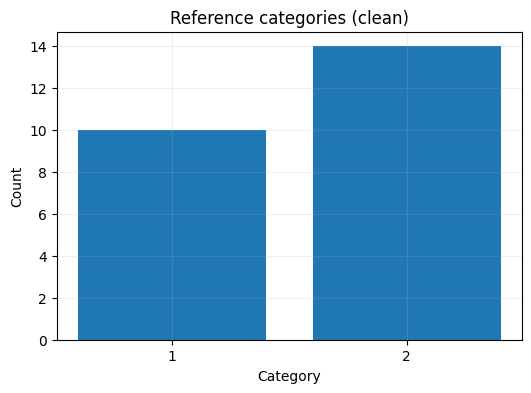

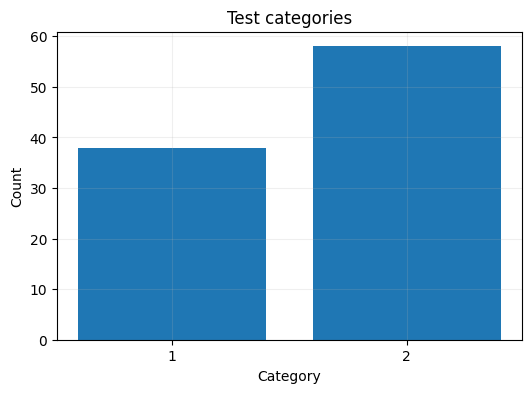

In [57]:
plot_category_histogram(res["y_all"], title="All GT categories")
plot_category_histogram(res["y_ref"], title="Reference categories (clean)")
plot_category_histogram(res["y_test"], title="Test categories")

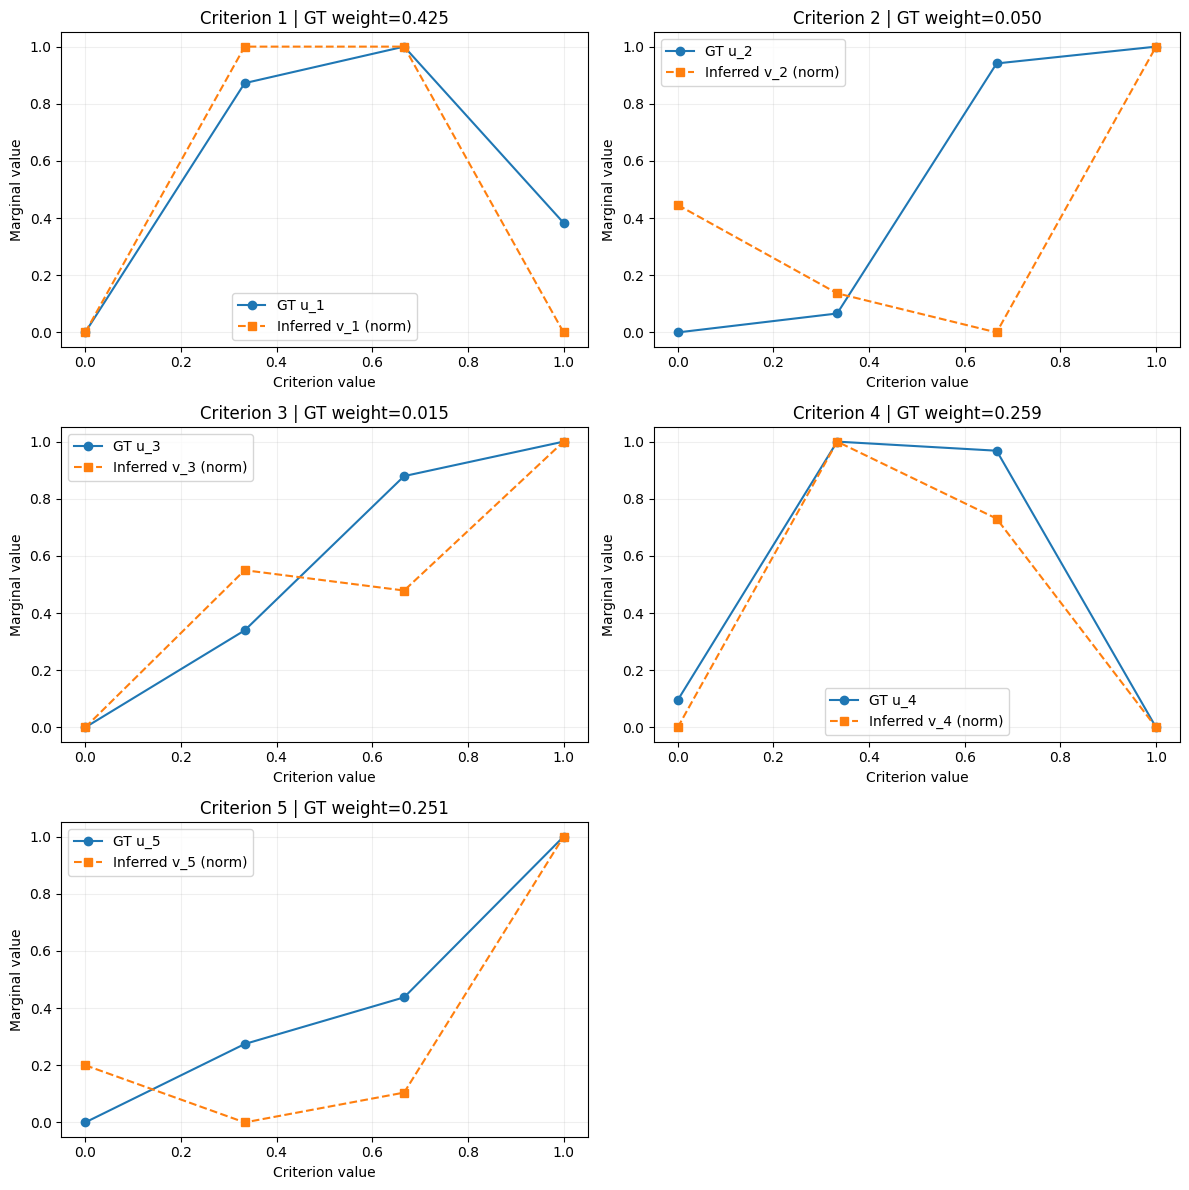

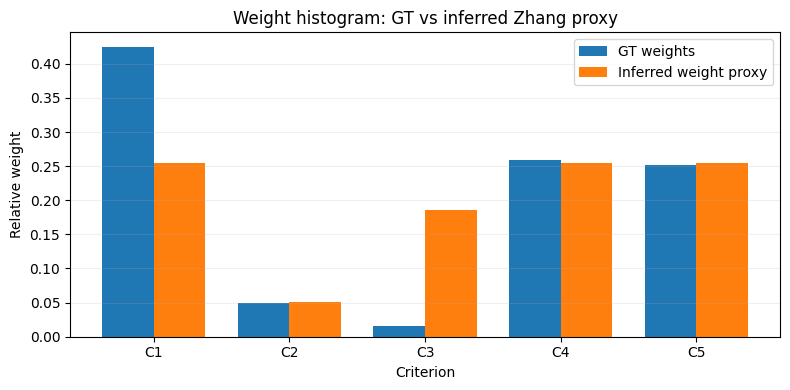

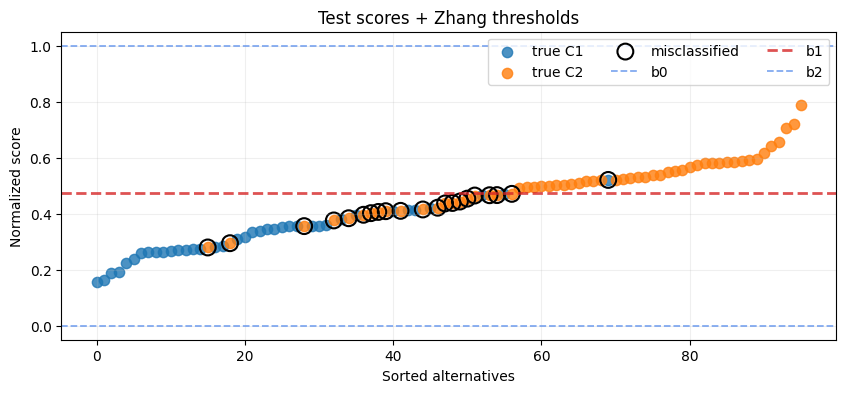

,score,y_true,y_pred
87,0.947685,1,1
57,0.981480,1,1
30,1.091500,1,1
24,1.109323,1,1
0,1.251289,1,1
14,1.316043,1,1
11,1.405169,1,1
35,1.418445,1,1
43,1.418733,1,1
82,1.421927,1,1


In [58]:
plot_marginals_and_weights(res["gt"], res["fit"])
plot_thresholds_and_scores(res["X_test"], res["fit"], y_true=res["y_test"], title="Test scores + Zhang thresholds")

## 3. Compare Approach 1 vs Approach 2

Même instance, deux approches lexicographiques.


In [59]:
res_a1 = run_trial_zhang(**{**CFG, "approach": 1})
res_a2 = run_trial_zhang(**{**CFG, "approach": 2})

cmp = pd.DataFrame([
    {
        "approach": "A1",
        "cpu_sec": res_a1["cpu_sec"],
        "epsilon": res_a1["epsilon"],
        "acc_train": res_a1["acc_train"],
        "acc_test": res_a1["acc_test"],
        "adj_acc_test": res_a1["adj_acc_test"],
        "mono_recovery_acc": res_a1["mono_recovery_acc"],
    },
    {
        "approach": "A2",
        "cpu_sec": res_a2["cpu_sec"],
        "epsilon": res_a2["epsilon"],
        "acc_train": res_a2["acc_train"],
        "acc_test": res_a2["acc_test"],
        "adj_acc_test": res_a2["adj_acc_test"],
        "mono_recovery_acc": res_a2["mono_recovery_acc"],
    },
])
cmp

,approach,cpu_sec,epsilon,acc_train,acc_test,adj_acc_test,mono_recovery_acc
0,A1,0.031022,0.001000,0.958333,0.822917,1.0,1.0
1,A2,0.013372,0.422825,0.958333,0.781250,1.0,0.4


## Protocol
We analyse the behaviour of the Zhang model under different experimental conditions.

We vary:
• the proportion of reference assignments
• the level of label noise
• the lexicographic approach used during optimisation

## 4. Small protocol — effect of reference ratio

Mini-grid légère, sans bruit, pour voir l'effet de la taille du learning set.


In [60]:
def run_grid_ref_ratio(
    ref_ratios=(0.2, 0.5, 0.8),
    seeds=(0, 1, 2),
    base_cfg=None,
):
    base_cfg = {} if base_cfg is None else dict(base_cfg)
    rows = []

    for rr in ref_ratios:
        for seed in seeds:
            cfg = {**base_cfg, "ref_ratio": rr, "seed": seed, "noise": 0.0}
            out = run_trial_zhang(**cfg)
            rows.append({
                "seed": seed,
                "ref_ratio": rr,
                "acc_test": out["acc_test"],
                "adj_acc_test": out["adj_acc_test"],
                "cpu_sec": out["cpu_sec"],
                "epsilon": out["epsilon"],
                "mono_recovery_acc": out["mono_recovery_acc"],
            })

    return pd.DataFrame(rows)

df_ref = run_grid_ref_ratio(
    ref_ratios=(0.2, 0.5, 0.8),
    seeds=(0, 1, 2),
    base_cfg={**CFG, "q": 3, "noise": 0.0, "approach": 2},
)
df_ref

,seed,ref_ratio,acc_test,adj_acc_test,cpu_sec,epsilon,mono_recovery_acc
0,0,0.2,0.510417,0.958333,0.016897,0.320145,0.2
1,1,0.2,0.593750,0.947917,0.014358,0.487542,0.4
2,2,0.2,0.833333,1.000000,0.013667,0.304603,0.4
3,0,0.5,0.716667,1.000000,0.033475,0.130047,0.4
4,1,0.5,0.650000,1.000000,0.032835,0.111343,0.4
5,2,0.5,0.866667,1.000000,0.027649,0.178915,0.4
6,0,0.8,0.875000,1.000000,0.040770,0.059523,0.6
7,1,0.8,0.791667,1.000000,0.042035,0.073428,0.6
8,2,0.8,0.958333,1.000000,0.048507,0.070987,1.0


In [61]:
df_ref.groupby("ref_ratio")[["acc_test", "adj_acc_test", "cpu_sec", "epsilon", "mono_recovery_acc"]].mean().round(4)

,acc_test,adj_acc_test,cpu_sec,epsilon,mono_recovery_acc
ref_ratio,,,,,
0.2,0.6458,0.9688,0.0150,0.3708,0.3333
0.5,0.7444,1.0000,0.0313,0.1401,0.4000
0.8,0.8750,1.0000,0.0438,0.0680,0.7333


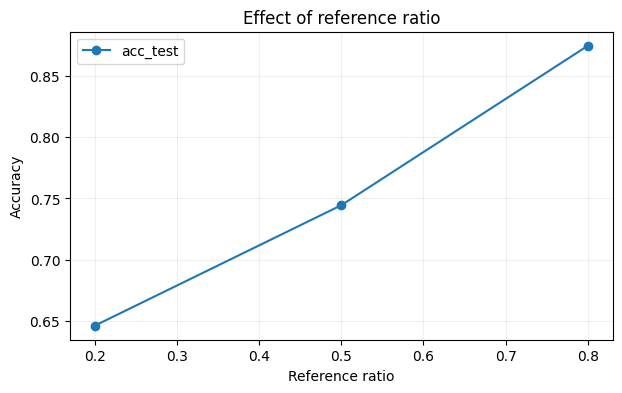

In [62]:
agg_ref = df_ref.groupby("ref_ratio", as_index=False)[["acc_test", "adj_acc_test"]].mean()
q_plot = int(CFG.get("q", 2))

plt.figure(figsize=(7, 4))
plt.plot(agg_ref["ref_ratio"], agg_ref["acc_test"], marker="o", label="acc_test")
if q_plot > 2:
    plt.plot(agg_ref["ref_ratio"], agg_ref["adj_acc_test"], marker="s", label="adj_acc_test")
plt.xlabel("Reference ratio")
plt.ylabel("Accuracy")
plt.title("Effect of reference ratio")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

## 5. Small protocol — effect of noise

Bruit sur les **reference assignments** uniquement.


In [63]:
def run_grid_noise(
    noise_levels=(0.0, 0.05, 0.10, 0.20),
    seeds=(0, 1, 2),
    base_cfg=None,
):
    base_cfg = {} if base_cfg is None else dict(base_cfg)
    rows = []

    for noise in noise_levels:
        for seed in seeds:
            cfg = {**base_cfg, "noise": noise, "seed": seed}
            out = run_trial_zhang(**cfg)
            rows.append({
                "seed": seed,
                "noise": noise,
                "acc_test": out["acc_test"],
                "adj_acc_test": out["adj_acc_test"],
                "cpu_sec": out["cpu_sec"],
                "epsilon": out["epsilon"],
                "used_adjustment": out["used_adjustment"],
            })

    return pd.DataFrame(rows)

df_noise = run_grid_noise(
    noise_levels=(0.0, 0.05, 0.10, 0.20),
    seeds=(0, 1, 2),
    base_cfg={**CFG, "ref_ratio": 0.5, "approach": 2},
)
df_noise

,seed,noise,acc_test,adj_acc_test,cpu_sec,epsilon,used_adjustment
0,0,0.00,0.866667,1.0,0.031493,0.253826,True
1,1,0.00,0.783333,1.0,0.039977,0.233177,True
2,2,0.00,0.800000,1.0,0.030726,0.383742,True
3,0,0.05,0.800000,1.0,0.028623,0.040960,True
4,1,0.05,0.716667,1.0,0.031212,0.155028,True
5,2,0.05,0.800000,1.0,0.029372,0.082924,True
6,0,0.10,0.800000,1.0,0.034622,0.101062,True
7,1,0.10,0.666667,1.0,0.029387,0.088937,True
8,2,0.10,0.700000,1.0,0.028335,0.017970,True
9,0,0.20,0.666667,1.0,0.043541,0.004095,True


In [64]:
df_noise.groupby("noise")[["acc_test", "adj_acc_test", "cpu_sec", "epsilon"]].mean().round(4)

,acc_test,adj_acc_test,cpu_sec,epsilon
noise,,,,
0.00,0.8167,1.0,0.0341,0.2902
0.05,0.7722,1.0,0.0297,0.0930
0.10,0.7222,1.0,0.0308,0.0693
0.20,0.6722,1.0,0.0759,0.0095


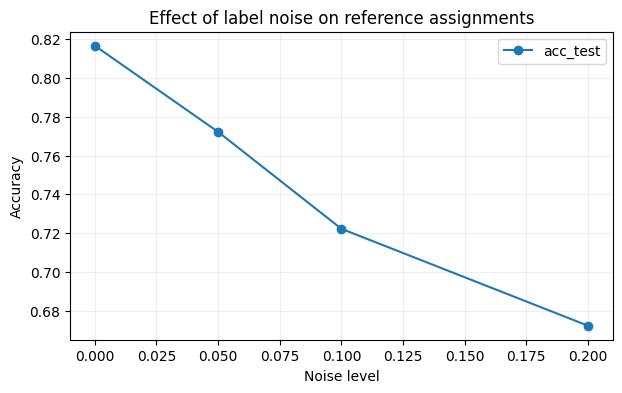

In [65]:
agg_noise = df_noise.groupby("noise", as_index=False)[["acc_test", "adj_acc_test"]].mean()
q_plot = int(CFG.get("q", 2))

plt.figure(figsize=(7, 4))
plt.plot(agg_noise["noise"], agg_noise["acc_test"], marker="o", label="acc_test")
if q_plot > 2:
    plt.plot(agg_noise["noise"], agg_noise["adj_acc_test"], marker="s", label="adj_acc_test")
plt.xlabel("Noise level")
plt.ylabel("Accuracy")
plt.title("Effect of label noise on reference assignments")
plt.grid(alpha=0.2)
plt.legend()
plt.show()